# 04 deep EDA

## Import

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml

import matplotlib as mpl
import matplotlib.pyplot as plt

import seaborn as sns

In [3]:
# Für Herrn Waack:
mpl.style.use("seaborn-v0_8-colorblind")

## Dataset & Splits

In [31]:
df_raw = fetch_openml(data_id=42742, as_frame=True).frame

In [32]:
df_raw.columns

Index(['target', 'ps_ind_01', 'ps_ind_02_cat', 'ps_ind_03', 'ps_ind_04_cat',
       'ps_ind_05_cat', 'ps_ind_06_bin', 'ps_ind_07_bin', 'ps_ind_08_bin',
       'ps_ind_09_bin', 'ps_ind_10_bin', 'ps_ind_11_bin', 'ps_ind_12_bin',
       'ps_ind_13_bin', 'ps_ind_14', 'ps_ind_15', 'ps_ind_16_bin',
       'ps_ind_17_bin', 'ps_ind_18_bin', 'ps_reg_01', 'ps_reg_02', 'ps_reg_03',
       'ps_car_01_cat', 'ps_car_02_cat', 'ps_car_03_cat', 'ps_car_04_cat',
       'ps_car_05_cat', 'ps_car_06_cat', 'ps_car_07_cat', 'ps_car_08_cat',
       'ps_car_09_cat', 'ps_car_10_cat', 'ps_car_11_cat', 'ps_car_11',
       'ps_car_12', 'ps_car_13', 'ps_car_14', 'ps_car_15', 'ps_calc_01',
       'ps_calc_02', 'ps_calc_03', 'ps_calc_04', 'ps_calc_05', 'ps_calc_06',
       'ps_calc_07', 'ps_calc_08', 'ps_calc_09', 'ps_calc_10', 'ps_calc_11',
       'ps_calc_12', 'ps_calc_13', 'ps_calc_14', 'ps_calc_15_bin',
       'ps_calc_16_bin', 'ps_calc_17_bin', 'ps_calc_18_bin', 'ps_calc_19_bin',
       'ps_calc_20_bin'],
      

In [33]:
memory_pre = df_raw.memory_usage(deep = True).sum() / 1024**2

In [34]:
# dtypes
feat_cols = [col for col in df_raw.columns if col not in ("target",)]
cat_cols = [col for col in feat_cols if col.endswith("_cat")] 
bin_cols = [col for col in feat_cols if col.endswith("_bin")] 
num_cols = [col for col in feat_cols if col not in cat_cols and col not in bin_cols]

for col in cat_cols:
    df_raw[col] = df_raw[col].astype("category")

for col in bin_cols:
    if df_raw[col].isna().sum() == 0:
        df_raw[col] = df_raw[col].astype(int).astype("bool")
    else:
        df_raw[col] = df_raw[col].astype("Int8")

for col in num_cols:
    df_raw[col] = df_raw[col].astype("float32")

df_raw["target"] = df_raw["target"].astype(int).astype("bool")

memory_post = df_raw.memory_usage(deep=True).sum() / 1024**2

print(f"{memory_pre:.2f} ; {memory_post:.2f}")

136.25 ; 77.21


In [35]:
idx_train = np.load("../../../data/processed/train_idx.npy")
idx_val = np.load("../../../data/processed/val_idx.npy")
idx_test = np.load("../../../data/processed/test_idx.npy")

df_train = df_raw.iloc[idx_train]
df_val = df_raw.iloc[idx_val]
df_test = df_raw.iloc[idx_test]

In [36]:
pd.Series({
    "raw" : len(df_raw),
    "train" : len(df_train),
    "val" : len(df_val),
    "test" : len(df_test)
})

raw      595212
train    476168
val       59522
test      59522
dtype: int64

## EDA

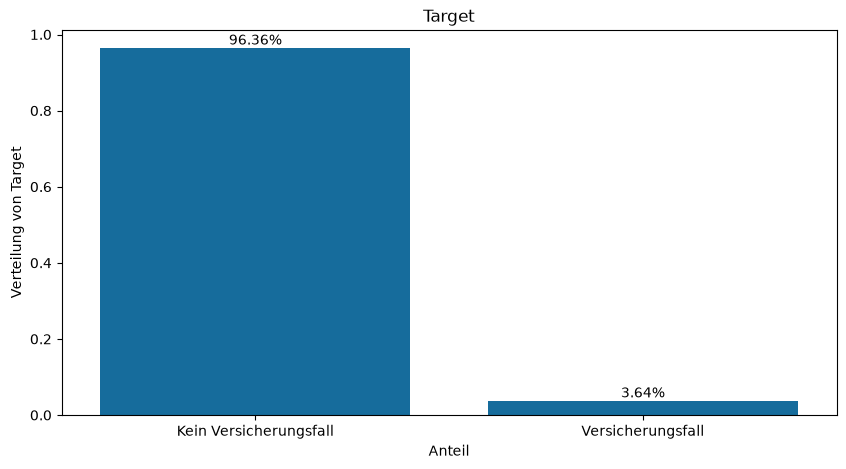

In [41]:
# Target

target_counts = df_raw["target"].value_counts(normalize=True).sort_index()
target_labels = {
    False : "Kein Versicherungsfall",
    True : "Versicherungsfall"
}
bar_labels = target_counts.index.map(target_labels)

fig, ax = plt.subplots(figsize = (10, 5))
sns.barplot(
    x=bar_labels,
    y=target_counts.values, ax=ax
)
ax.set_title("Target")
ax.set_xlabel("Anteil")
ax.set_ylabel("Verteilung von Target")

for x, y in enumerate(target_counts.values):
    ax.text(x, y+0.01, f"{y:.2%}", ha="center")

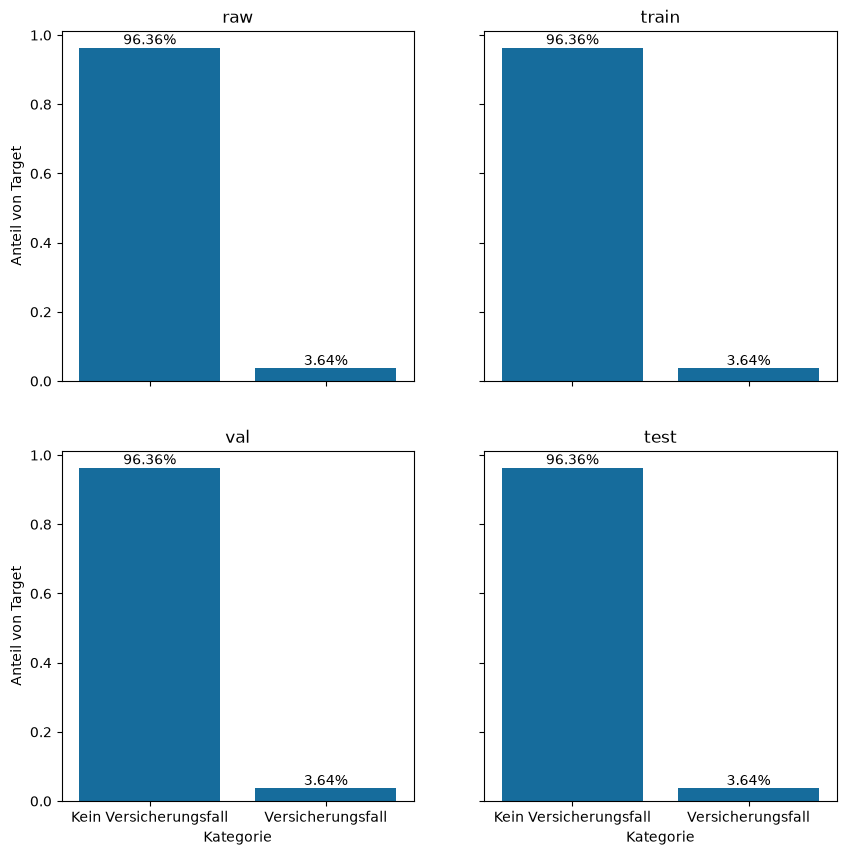

In [45]:
fig, axes = plt.subplots(2,2,figsize=(10,10), sharex=True, sharey=True)

for data_name, data, ax in zip(["raw", "train", "val", "test"], [df_raw, df_train, df_val, df_test], axes.flatten()):
    target_counts = data["target"].value_counts(normalize=True).sort_index()
    target_labels = {
        False : "Kein Versicherungsfall",
        True : "Versicherungsfall"
    }
    bar_labels = target_counts.index.map(target_labels)

    sns.barplot(
        x=bar_labels,
        y=target_counts.values, ax=ax
    )
    ax.set_title(data_name)
    ax.set_xlabel("Kategorie")
    ax.set_ylabel("Anteil von Target")

    for x, y in enumerate(target_counts.values):
        ax.text(x, y+0.01, f"{y:.2%}", ha="center")

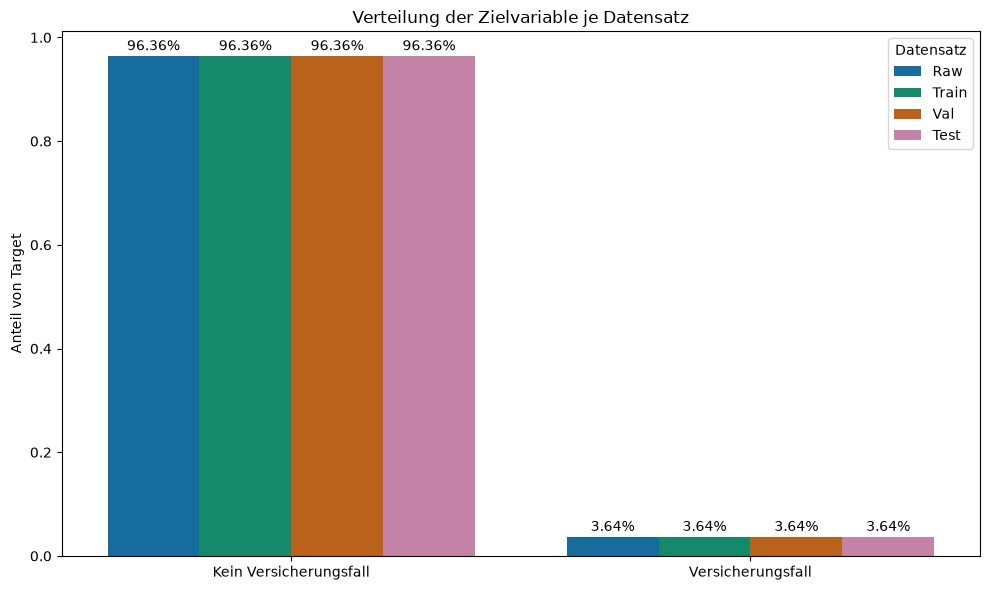

In [47]:
datasets = {
    "Raw": df_raw, 
    "Train": df_train, 
    "Val": df_val, 
    "Test": df_test
}
target_labels = {
    False : "Kein Versicherungsfall",
    True : "Versicherungsfall"
}

rows = []
for name, data in datasets.items():
    counts = data["target"].value_counts(normalize=True).sort_index()
    for value, share in counts.items():
        rows.append({"Datensatz": name, "Target": target_labels[value], "Anteil": share})

plot_df = pd.DataFrame(rows)
plot_df

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=plot_df, x="Target", y="Anteil", hue="Datensatz", ax=ax)

ax.set_title("Verteilung der Zielvariable je Datensatz")
ax.set_xlabel("")
ax.set_ylabel("Anteil von Target")

for container in ax.containers:
    labels = [f"{v:.2%}" for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=2)

plt.tight_layout()

Ergebnisse